# [LAB 07] 11. 다중 공선성
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
from hossam import load_data
from helpers import *
from pandas import DataFrame, concat

# 연속형 자료형에서 값의 조합을 생성하는 함수
from itertools import combinations

# VIF 계산을 위한 statsmodels 패키지
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기

In [2]:
df = load_data('vif_housing')
df

📚 어느 부동산 중개사무소에서 아파트 매물 250건의 정보를 수집하여 아파트 가격에 영향을 미치는 요인을 분석하기 위해 조사한 가상의 데이터


,면적_m2,면적_평,방_개수,지하철_거리_m,건물_연식_년
0,91.313,27.512,5.000,603.206,15.238
1,59.040,17.962,3.000,516.206,9.257
2,102.011,31.377,4.000,315.781,13.179
3,106.574,31.942,4.000,1173.652,20.700
4,37.175,11.172,1.000,1099.847,13.508
...,...,...,...,...,...
245,53.102,16.344,3.000,698.762,14.600
246,57.677,16.898,3.000,814.710,11.422
247,128.086,38.645,6.000,633.930,4.470
248,153.722,45.903,6.000,636.614,16.948


## #02. 여러 변수의 상관 분석
### 1. 각 변수들간의 조합 쌍 생성
- VIF를 계산하기 전에, 먼저 상관행렬로 변수들이 얼마나 닮았는지 눈으로 확인

In [3]:
# df의 컬럼명에 대한 조합 쌍을 생성한다.
column_pairs = list(combinations(df.columns, 2))
column_pairs

[('면적_m2', '면적_평'),
 ('면적_m2', '방_개수'),
 ('면적_m2', '지하철_거리_m'),
 ('면적_m2', '건물_연식_년'),
 ('면적_평', '방_개수'),
 ('면적_평', '지하철_거리_m'),
 ('면적_평', '건물_연식_년'),
 ('방_개수', '지하철_거리_m'),
 ('방_개수', '건물_연식_년'),
 ('지하철_거리_m', '건물_연식_년')]

### 2. 변수 조합별 상관분석
- 데이터프레임 객체의 corr() 메서드는 변수 조합별로 가정 확인 없이 일관된 상관 계수를 도출하기 때문에 각각 상관분석을 수행하여 적절한 상관계수(Pearson, Spearman)를 도출해야 한다.

In [4]:
corr_df = DataFrame()
for col1, col2 in column_pairs:
    corr = my_stats.correlation(df, col1, col2, plot=False)
    corr_df = concat([corr_df, corr])

corr_df

method   coef  p-value strength  significant  \
x        y                                                          
면적_m2    면적_평      Spearman  0.999    0.000   Strong         True   
         방_개수      Spearman  0.897    0.000   Strong         True   
         지하철_거리_m  Spearman -0.087    0.171     Weak        False   
         건물_연식_년   Spearman  0.156    0.013     Weak         True   
면적_평     방_개수       Pearson  0.901    0.000   Strong         True   
         지하철_거리_m   Pearson -0.092    0.147     Weak        False   
         건물_연식_년    Pearson  0.160    0.011     Weak         True   
방_개수     지하철_거리_m   Pearson -0.098    0.121     Weak        False   
         건물_연식_년    Pearson  0.116    0.066     Weak        False   
지하철_거리_m 건물_연식_년    Pearson  0.081    0.204     Weak        False   

                   normality_x  normality_y  linearity  influential_outlier  \
x        y                                                                    
면적_m2    면적_평            False         True      False                False   
         방_개수            False         True       True                False   
         지하철_거리_m        False         True       True                False   
         건물_연식_년         False         True       True                False   
면적_평     방_개수             True         True       True                False   
         지하철_거리_m         True         True       True                False   
         건물_연식_년          True         True       True                False   
방_개수     지하철_거리_m         True         True       True                False   
         건물_연식_년          True         True       True                False   
지하철_거리_m 건물_연식_년          True         True       True                False   

                   high_skew  
x        y                    
면적_m2    면적_평          False  
         방_개수          False  
         지하철_거리_m      False  
         건물_연식_년       False  
면적_평     방_개수          False  
         지하철_거리_m      False  
         건물_연식_년       False  
방_개수     지하철_거리_m      False  
         건물_연식_년       False  
지하철_거리_m 건물_연식_년       False

- 다중공선성이 의심되는 변수 관계
    - 면적_m2 <-> 면적_평 : 0.999
    - 면적_m2 <-> 방_개수 : 0.897
    - 면적_평 <-> 방_개수 : 0.901

### 3. 상관행렬로 결과표 재배치

In [5]:
# corr_df의 상관계수(coef)를 정방형 상관행렬(산점도 행렬)로 변환한다.
cols =list(df.columns)

# 대각선(자기 자신과의 상관)은 1.0d으로 초기화
corr_matrix = DataFrame(1.0, index=cols, columns=cols)

# 각 변수 조합의 상관계수를 대칭이 되도록 양쪽에 채운다.
for (col1, col2), coef in corr_df['coef'].items():
    corr_matrix.loc[col1, col2] = coef
    corr_matrix.loc[col2, col1] = coef

# 배경 색상(그라데이션)을 적용해서 출력
corr_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.3f}')

,면적_m2,면적_평,방_개수,지하철_거리_m,건물_연식_년
면적_m2,1.000,0.999,0.897,-0.087,0.156
면적_평,0.999,1.000,0.901,-0.092,0.160
방_개수,0.897,0.901,1.000,-0.098,0.116
지하철_거리_m,-0.087,-0.092,-0.098,1.000,0.081
건물_연식_년,0.156,0.160,0.116,0.081,1.000


### 4. 산점도 행렬 시각화

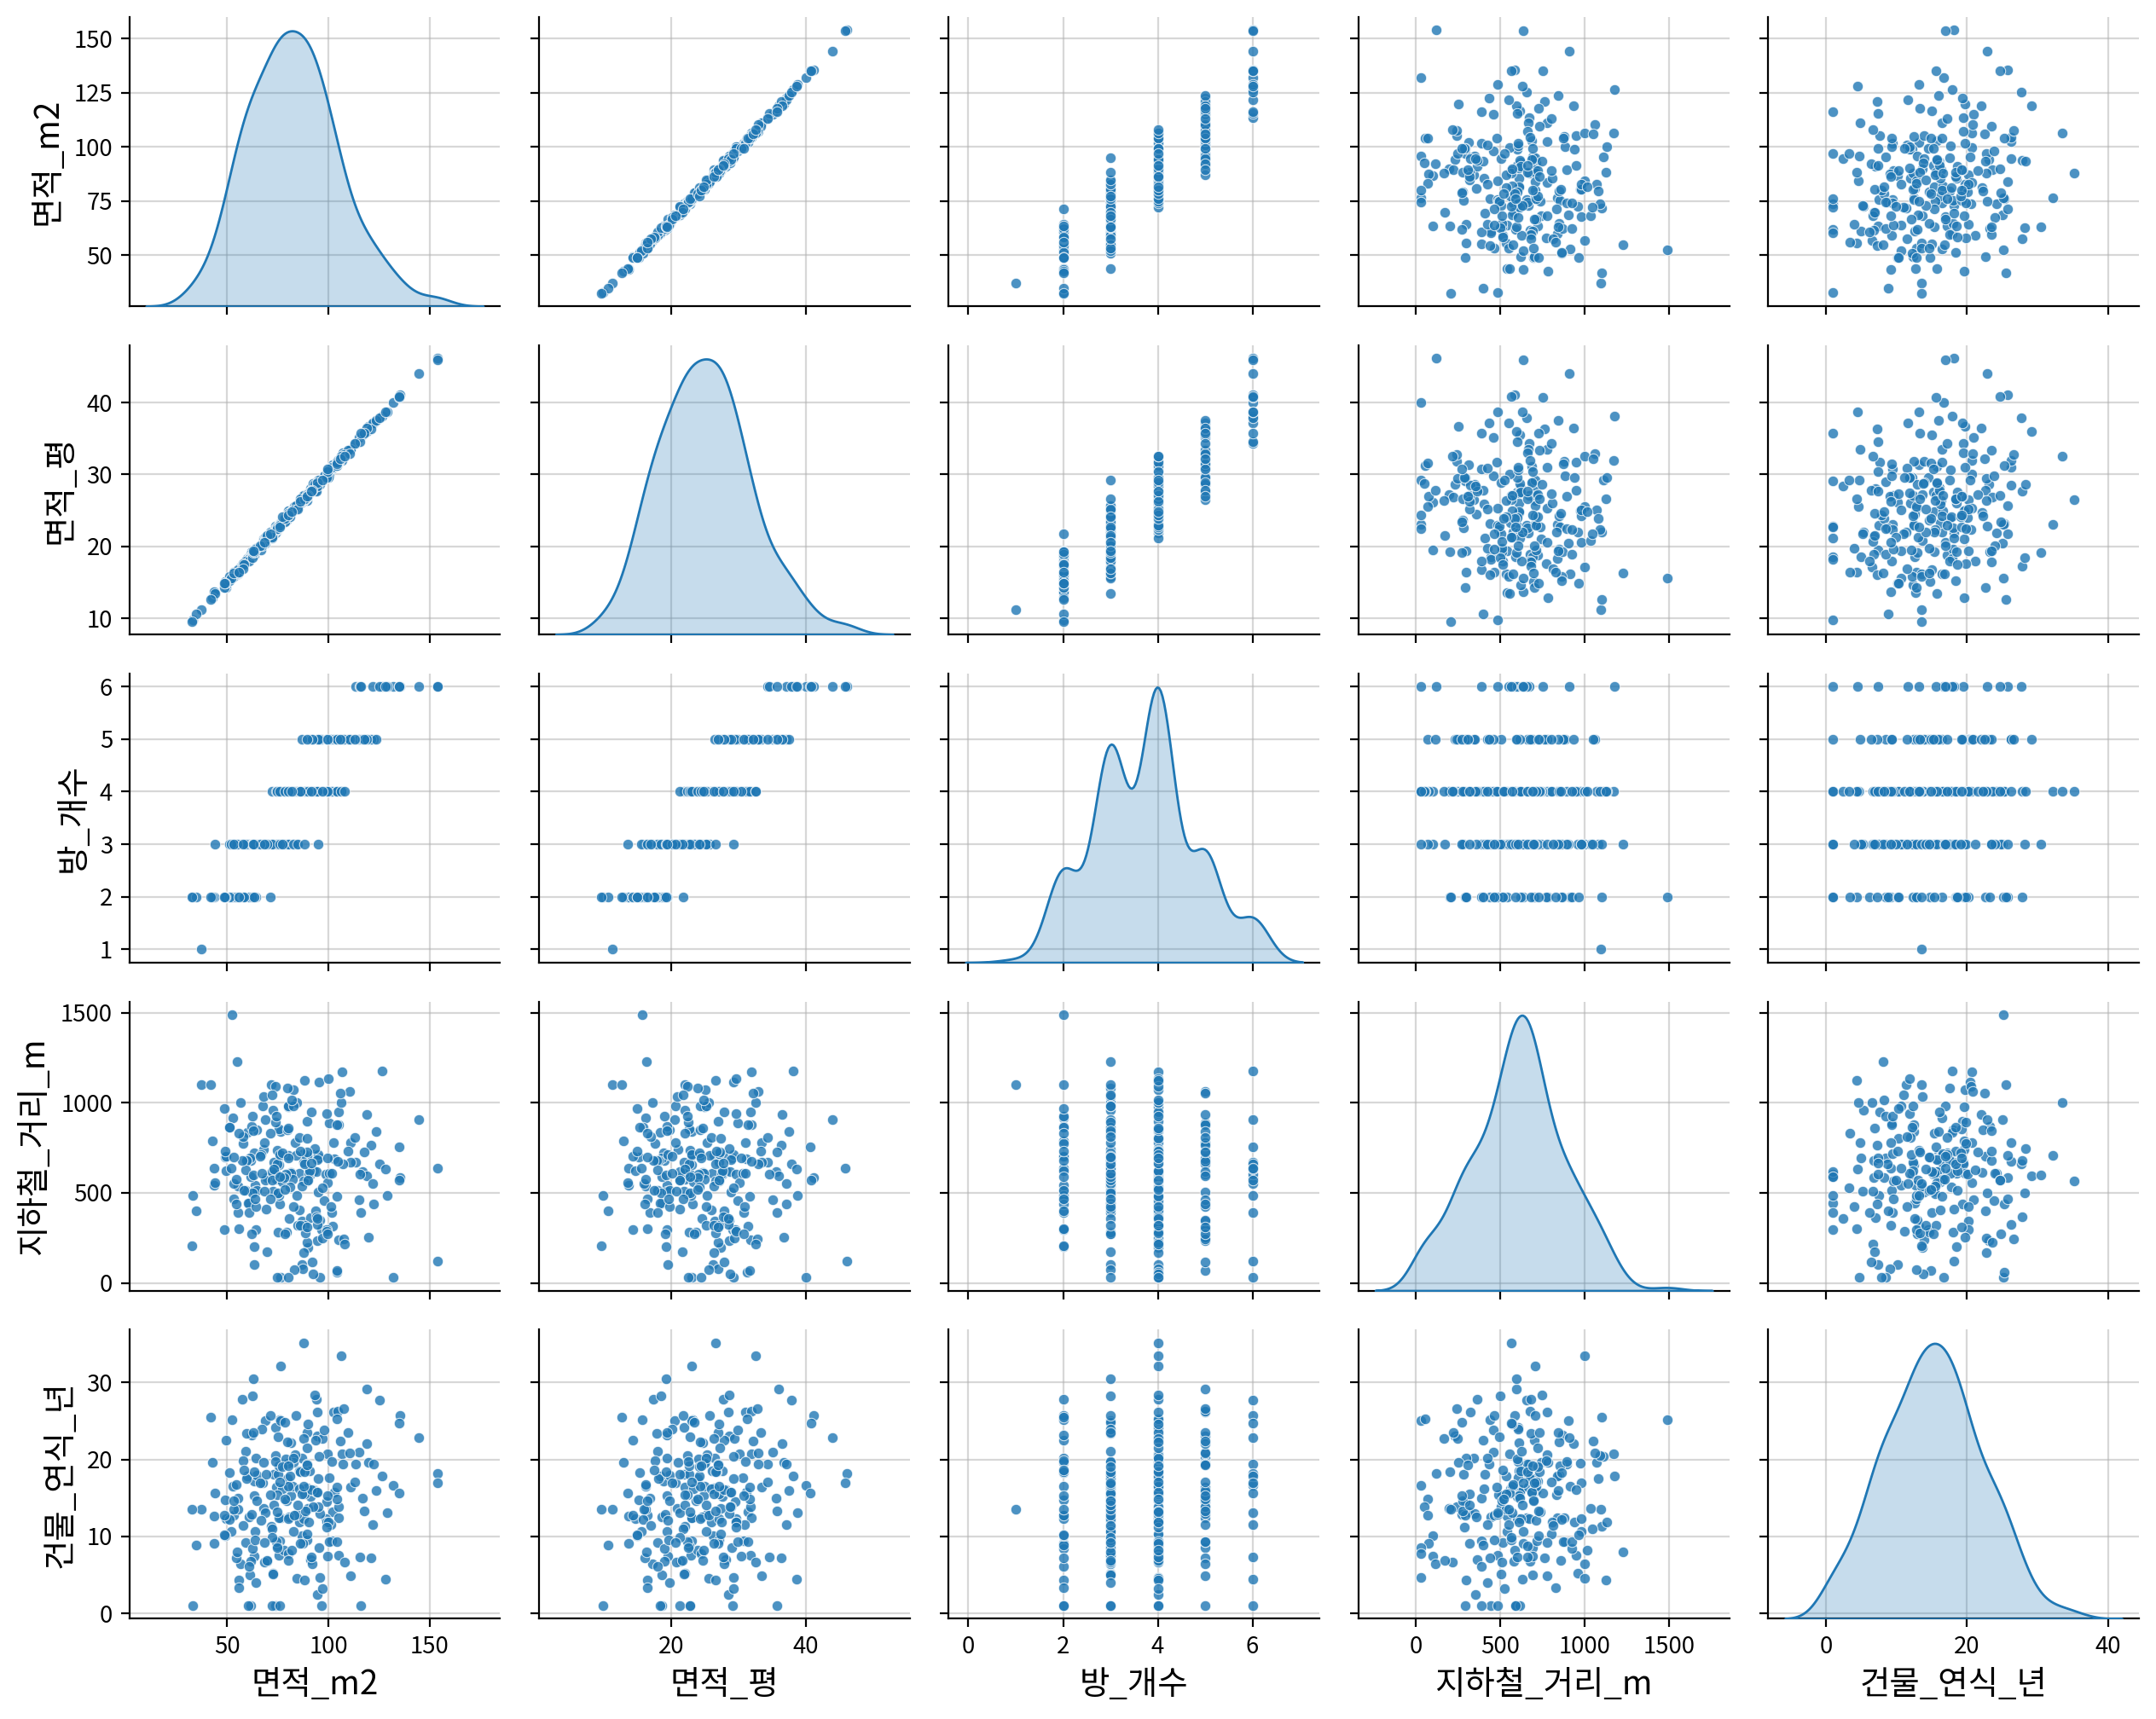

In [6]:
my_plot.pairplot(df, width=1280, height=1024)

### 5. 모듈화 기능 확인

method   coef  p-value strength  significant  \
x        y                                                          
면적_m2    면적_평      Spearman  0.999    0.000   Strong         True   
         방_개수      Spearman  0.897    0.000   Strong         True   
         지하철_거리_m  Spearman -0.087    0.171     Weak        False   
         건물_연식_년   Spearman  0.156    0.013     Weak         True   
면적_평     방_개수       Pearson  0.901    0.000   Strong         True   
         지하철_거리_m   Pearson -0.092    0.147     Weak        False   
         건물_연식_년    Pearson  0.160    0.011     Weak         True   
방_개수     지하철_거리_m   Pearson -0.098    0.121     Weak        False   
         건물_연식_년    Pearson  0.116    0.066     Weak        False   
지하철_거리_m 건물_연식_년    Pearson  0.081    0.204     Weak        False   

                   normality_x  normality_y  linearity  influential_outlier  \
x        y                                                                    
면적_m2    면적_평            False         True      False                False   
         방_개수            False         True       True                False   
         지하철_거리_m        False         True       True                False   
         건물_연식_년         False         True       True                False   
면적_평     방_개수             True         True       True                False   
         지하철_거리_m         True         True       True                False   
         건물_연식_년          True         True       True                False   
방_개수     지하철_거리_m         True         True       True                False   
         건물_연식_년          True         True       True                False   
지하철_거리_m 건물_연식_년          True         True       True                False   

                   high_skew  
x        y                    
면적_m2    면적_평          False  
         방_개수          False  
         지하철_거리_m      False  
         건물_연식_년       False  
면적_평     방_개수          False  
         지하철_거리_m      False  
         건물_연식_년       False  
방_개수     지하철_거리_m      False  
         건물_연식_년       False  
지하철_거리_m 건물_연식_년       False

,면적_m2,면적_평,방_개수,지하철_거리_m,건물_연식_년
면적_m2,1.000,0.999,0.897,-0.087,0.156
면적_평,0.999,1.000,0.901,-0.092,0.160
방_개수,0.897,0.901,1.000,-0.098,0.116
지하철_거리_m,-0.087,-0.092,-0.098,1.000,0.081
건물_연식_년,0.156,0.160,0.116,0.081,1.000


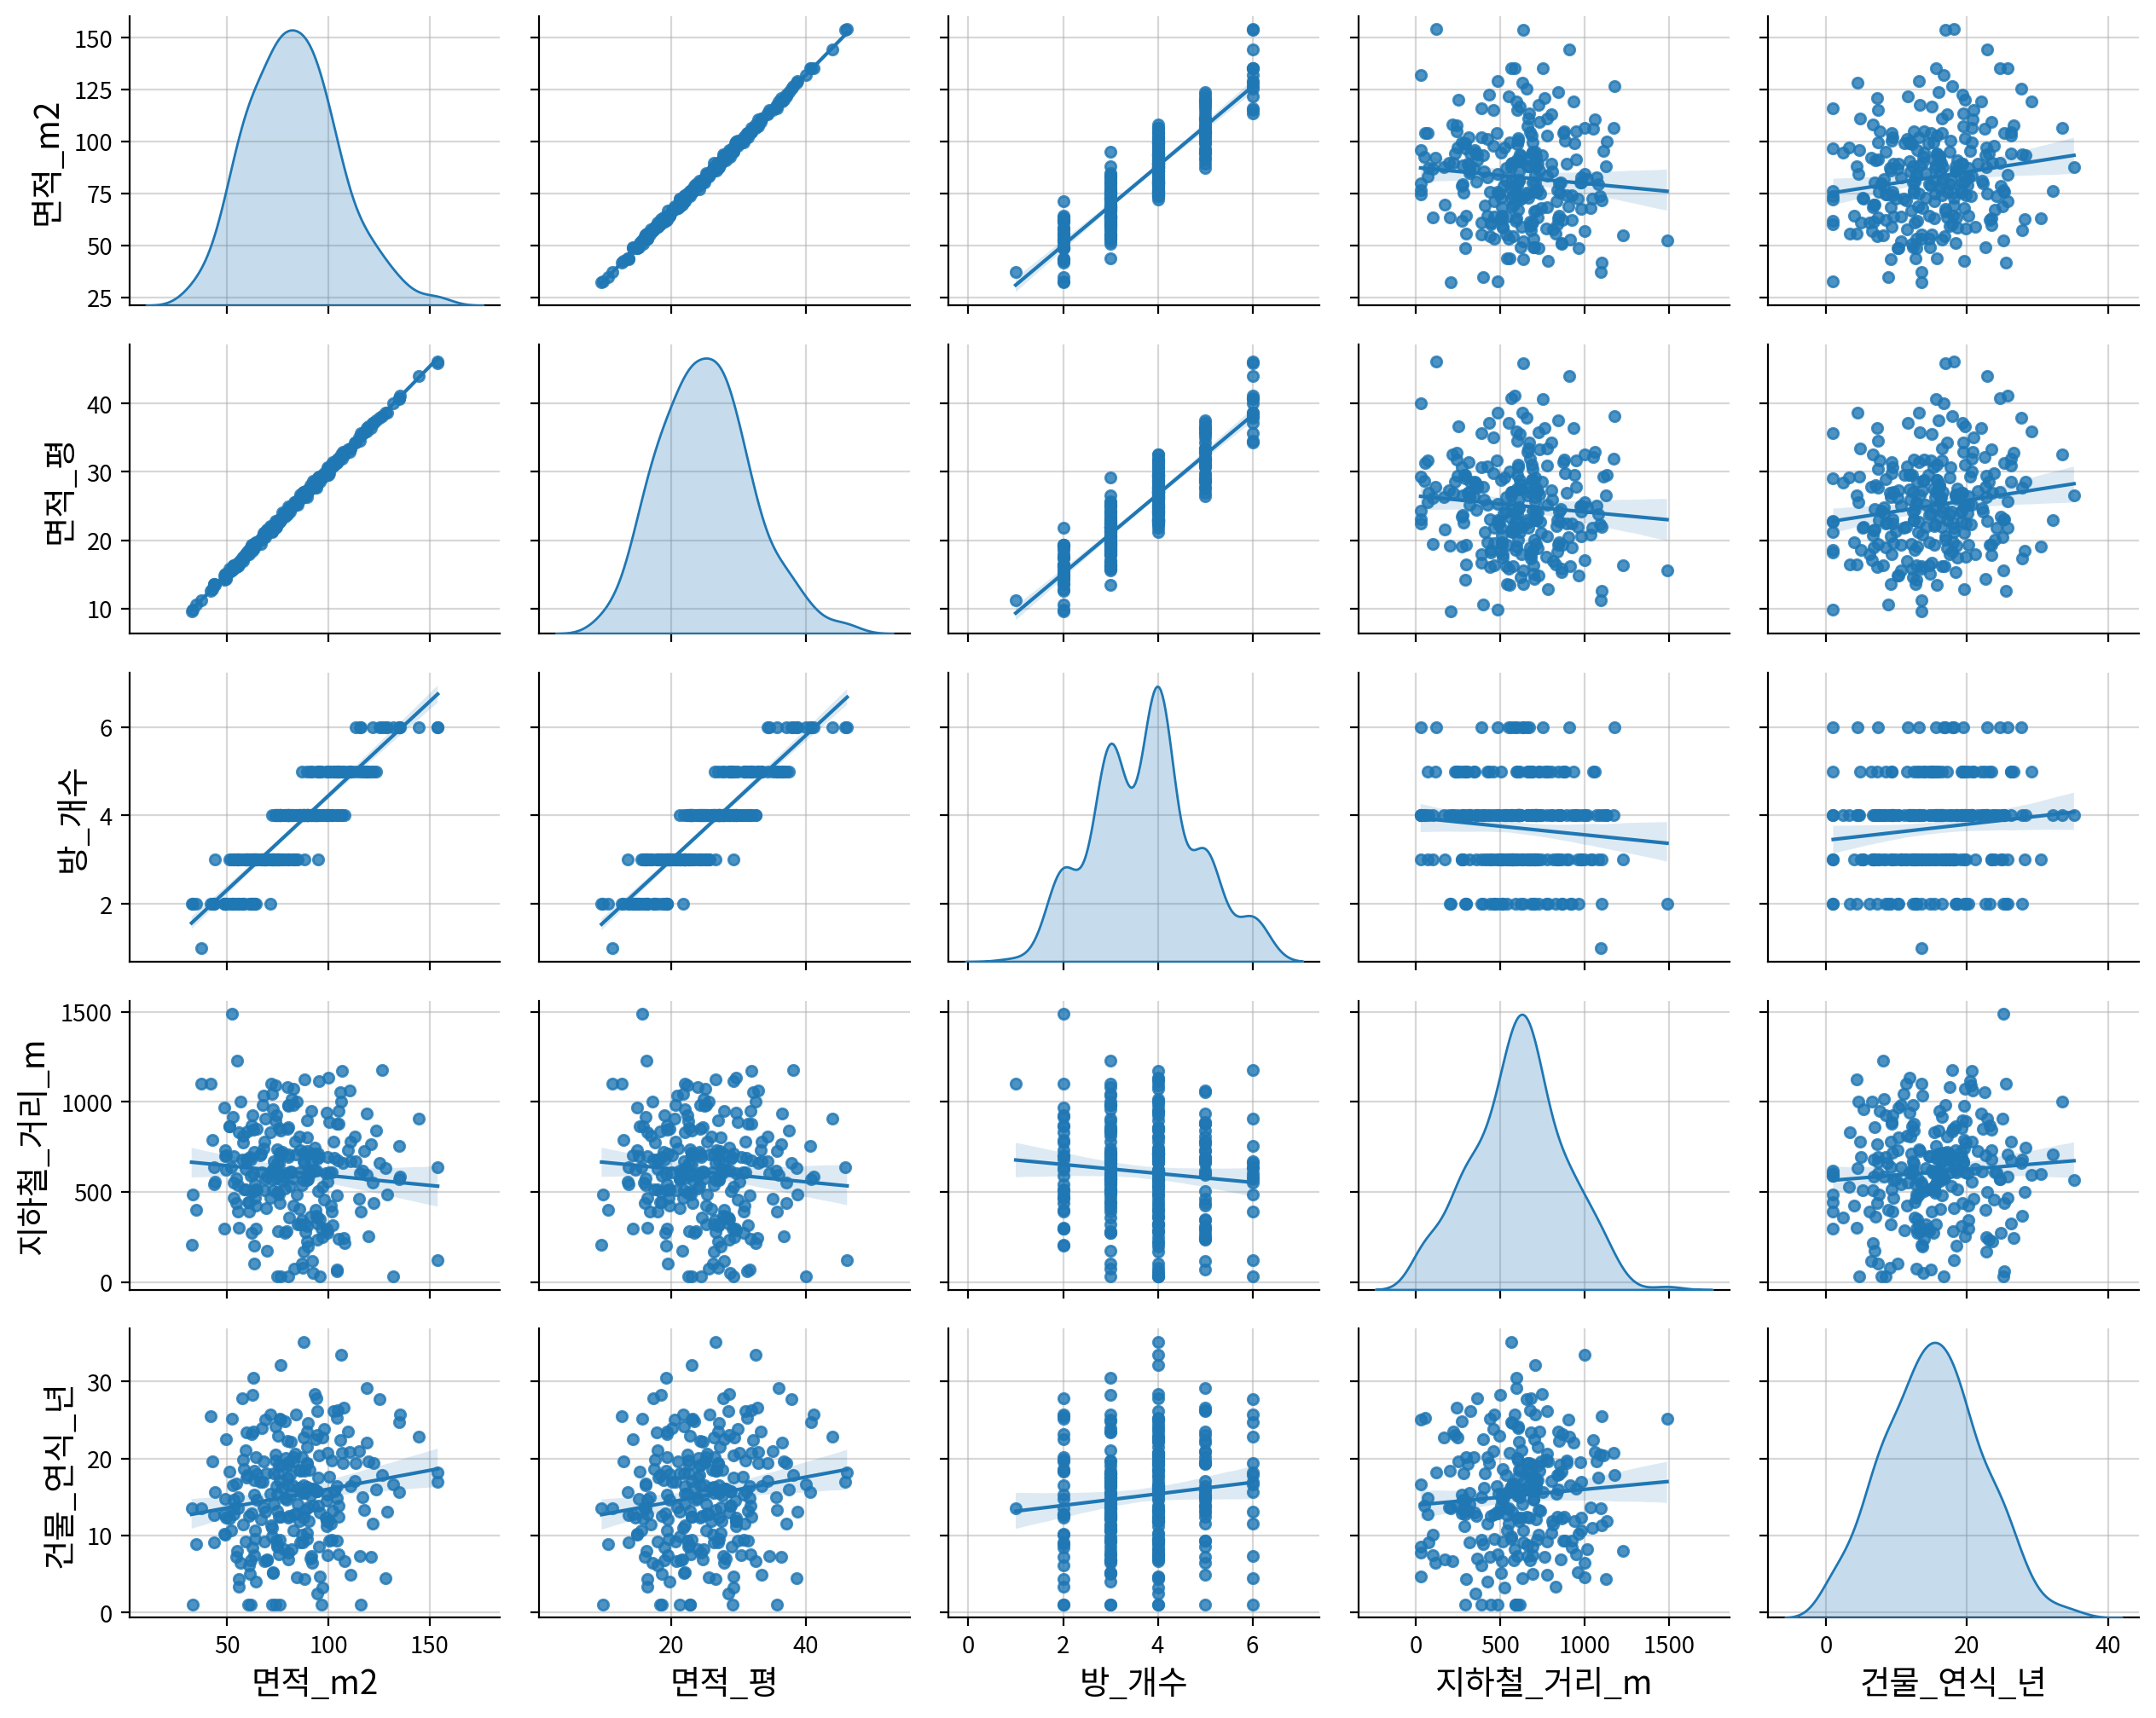

In [7]:
my_stats.multi_correlation(df, width=1280, height=1024)

## #03. 다중 공선성 제거
### 1. VIF 계산 함수 정의

In [8]:
def compute_vif(df, columns=None):
    """
    각 변수의 VIF 를 statsmodels 패키지로 계산해서 반환.
    """

    # 처리 대상 컬럼 결정: 지정이 없으면 수치형 컬럼만 자동 선택
    if columns is None:
        target = df.select_dtypes(include='number')
    else:
        # df 에 존재하지 않는 컬럼이 들어오면 명확하게 알려준다
        missing = [c for c in columns if c not in df.columns]
        if missing:
            raise KeyError(f'df 에 존재하지 않는 컬럼입니다: {missing}')

        target = df[columns]

        # VIF 는 수치 행렬 연산이므로 비수치형이 섞이면 안 된다
        non_numeric = list(target.select_dtypes(exclude='number').columns)
        if non_numeric:
            raise TypeError(f'수치형이 아닌 컬럼은 VIF 를 계산할 수 없습니다: {non_numeric}')

    # 회귀모형에 절편(상수항)이 있어야 올바른 VIF 가 나오므로 절편(상수항)을 추가
    X = add_constant(target)

    # 각 변수(열)별로 VIF 를 하나씩 계산해서 리스트에 담는다.
    vif_values = []

    # 각 변수에 대해 VIF 를 계산
    for i in range(X.shape[1]):
        # variance_inflation_factor 는 i 번째 변수에 대한 VIF 를 계산
        vif_i = variance_inflation_factor(X.values, i)
        vif_values.append(vif_i)

    # 계산한 VIF 값들을 변수명과 함께 DataFrame 으로 정리
    vif = DataFrame({'VIF': vif_values}, index=X.columns)

    # 상수항(const)은 분석 대상이 아니므로 제외하고 VIF 기준 내림차순 정렬해서 반환
    return vif.drop('const').sort_values(by='VIF', ascending=False)

### 2. 구현한 함수 확인

In [9]:
vif = compute_vif(df)
vif

,VIF
면적_m2,546.195
면적_평,545.222
방_개수,5.352
건물_연식_년,1.040
지하철_거리_m,1.019


### 3. VIF가 가장 큰 변수 제거
- 변수 하나만 제거하더라도 모든 VIF 값이 변하기 때문에 일괄 삭제해서는 안된다.

In [10]:
# VIF 컬럼의 최대값을 갖는 인덱스명 반환 --> "면적_m2"
worst = vif['VIF'].idxmax()
print(f'가장 VIF가 큰 변수: {worst} (VIF = {vif["VIF"].max():.1f}) -> 제거')

# 원본 데이터프레임에서 가장 VIF가 큰 컬럼을 제거한 새로운 데이터프레임 생성
df_reduced = df.drop(columns=[worst])

# VIF 재계산
compute_vif(df_reduced)

가장 VIF가 큰 변수: 면적_m2 (VIF = 546.2) -> 제거


,VIF
면적_평,5.400
방_개수,5.336
건물_연식_년,1.040
지하철_거리_m,1.019


### 4. 무한루프로 다중공선성이 사라질때까지 반복제거
- 한개를 제거한 후 모든 변수의 VIF가 재산정되며 여전히 VIF값이 10보다 큰 변수가 존재할 수 있다.
- 그러므로 VIF가 10보다 큰 변수가 모두 사라질 때까지 반복적으로 이 작업을 수행해야한다.

In [11]:
threshold = 10.0    # VIF 기준값
work = df.copy()    # 원본을 보존하기 위해 복사본으로 작업
step = 0            # 반복 단계 카운터

while True:         # 무한루프
    vif = compute_vif(work)         # VIF 계산
    max_vif = vif['VIF'].max()      # 가장 큰 VIF 값

    # 종료 조건: 가장 큰 VIF도 기준 미만이거나 남은 변수가 한개라면 종료
    if max_vif < threshold or len(work.columns) <= 1:
        print(f'\n완료! 남은 변수: {list(work.columns)}')
        print(f'최대 VIF = {max_vif:.2f}')
        break

    # 가장 VIF 가 큰 변수를 찾아 제거하고 다시 반복
    worst = vif['VIF'].idxmax()
    step += 1
    print(f'[{step}단계] {worst} 제거 (VIF = {max_vif:.1f}) | 남은 변수: {list(work.columns)}')
    work = work.drop(columns=[worst])

# 최종적으로 다중공선성이 제거된 데이터프레임
df_final = work
df_final

[1단계] 면적_m2 제거 (VIF = 546.2) | 남은 변수: ['면적_m2', '면적_평', '방_개수', '지하철_거리_m', '건물_연식_년']

완료! 남은 변수: ['면적_평', '방_개수', '지하철_거리_m', '건물_연식_년']
최대 VIF = 5.40


,면적_평,방_개수,지하철_거리_m,건물_연식_년
0,27.512,5.000,603.206,15.238
1,17.962,3.000,516.206,9.257
2,31.377,4.000,315.781,13.179
3,31.942,4.000,1173.652,20.700
4,11.172,1.000,1099.847,13.508
...,...,...,...,...
245,16.344,3.000,698.762,14.600
246,16.898,3.000,814.710,11.422
247,38.645,6.000,633.930,4.470
248,45.903,6.000,636.614,16.948


## #04. 모듈화 기능 테스트
### 1. 다중 공선성 제거

In [12]:
df_final2 = my_prep.reduce_vif(df, threshold=10.0)
df_final2

[1단계] 면적_m2 제거 (VIF = 546.2)

완료! 남은 변수: ['면적_평', '방_개수', '지하철_거리_m', '건물_연식_년']
최대 VIF = 5.40


,면적_평,방_개수,지하철_거리_m,건물_연식_년
0,27.512,5.000,603.206,15.238
1,17.962,3.000,516.206,9.257
2,31.377,4.000,315.781,13.179
3,31.942,4.000,1173.652,20.700
4,11.172,1.000,1099.847,13.508
...,...,...,...,...
245,16.344,3.000,698.762,14.600
246,16.898,3.000,814.710,11.422
247,38.645,6.000,633.930,4.470
248,45.903,6.000,636.614,16.948


### 2. 다중 공선성이 제거된 데이터의 VIF 확인

In [13]:
my_stats.compute_vif(df_final2)

,VIF
면적_평,5.400
방_개수,5.336
건물_연식_년,1.040
지하철_거리_m,1.019


### 3. 다중 공선성이 제거된 데이터의 상관분석

In [14]:
my_stats.multi_correlation(df_final2, plot=False)

method   coef  p-value strength  significant  normality_x  \
x        y                                                                      
면적_평     방_개수      Pearson  0.901    0.000   Strong         True         True   
         지하철_거리_m  Pearson -0.092    0.147     Weak        False         True   
         건물_연식_년   Pearson  0.160    0.011     Weak         True         True   
방_개수     지하철_거리_m  Pearson -0.098    0.121     Weak        False         True   
         건물_연식_년   Pearson  0.116    0.066     Weak        False         True   
지하철_거리_m 건물_연식_년   Pearson  0.081    0.204     Weak        False         True   

                   normality_y  linearity  influential_outlier  high_skew  
x        y                                                                 
면적_평     방_개수             True       True                False      False  
         지하철_거리_m         True       True                False      False  
         건물_연식_년          True       True                False      False  
방_개수     지하철_거리_m         True       True                False      False  
         건물_연식_년          True       True                False      False  
지하철_거리_m 건물_연식_년          True       True                False      False

,면적_평,방_개수,지하철_거리_m,건물_연식_년
면적_평,1.000,0.901,-0.092,0.160
방_개수,0.901,1.000,-0.098,0.116
지하철_거리_m,-0.092,-0.098,1.000,0.081
건물_연식_년,0.160,0.116,0.081,1.000
